# 6. Special relativistic hydrodynamics: primitive variables, reconstruction, and Riemann solvers

Jets from active galactic nuclei and gamma-ray bursts move with Lorentz factors of ten and more, and
the gas near compact objects is often relativistically hot. The equations of special relativistic
hydrodynamics (rHD) are still a system of conservation laws, and Piastra solves them with the same
finite-volume machinery as in the Newtonian case. Two steps, however, become genuinely new:

* the conversion from conserved to primitive variables has no closed form and requires the solution of
  a nonlinear equation in every cell at every stage;
* the reconstruction must respect the speed of light, a nonlinear constraint on the velocity *vector*.

This notebook explains both, then compares the three Riemann solvers of the rHD module on standard
one-dimensional problems, and ends with a relativistic jet. Units with $c = 1$ are used throughout.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from src.common.eos_setup import EOSdata
from src.common.high_order_rec import VarReconstruct
from src.models.rHD.rHD_phys import prim2cons_rHD, cons2prim_rHD, _pres_eqn_sr, _pres_der_sr
from main import SOLVER_DISPATCH


def setup(problem, N1, N2=1, **options):
    '''Parameters, grid, state, EOS and solver for a relativistic hydrodynamics problem.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="rHD", problem=problem, Nx1=N1, Nx2=N2, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        solver = SOLVER_DISPATCH["rHD"](grid, state, eos, par)
    return grid, state, par, eos, solver


def evolve(solver, par, t_end=None):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    with contextlib.redirect_stdout(io.StringIO()):
        while par.timenow < par.timefin - 1e-12:
            state = solver.step_RK()
    return state


def profile(grid, array):
    '''Cell centres and values along x1 (interior cells of a 1D run).'''
    g = grid.Ngc
    return grid.cx1[g:-g, g], array[g:-g, g].copy()


def interior(grid, array):
    g = grid.Ngc
    return array[g:-g, g:-g].copy()

## 1. The equations

The rest-frame density $\rho$, velocity $\mathbf{v}$ ($|\mathbf{v}| < 1$), and pressure $p$ are the
**primitive** variables. The laboratory-frame **conserved** variables are the density, the momentum,
and the total energy (Piastra includes the rest-mass energy in $E$):

$$D = \rho W, \qquad \mathbf{S} = \rho h W^2\,\mathbf{v}, \qquad E = \rho h W^2 - p,$$

with the Lorentz factor $W = 1/\sqrt{1 - v^2}$ and the specific enthalpy $h = 1 + \frac{\gamma}{\gamma-1}\frac{p}{\rho}$
of an ideal gas. They obey

$$\partial_t D + \nabla\cdot(D\mathbf{v}) = 0, \qquad
  \partial_t \mathbf{S} + \nabla\cdot(\mathbf{S}\mathbf{v} + p\,\mathsf{I}) = 0, \qquad
  \partial_t E + \nabla\cdot\mathbf{S} = 0 .$$

The structure is the same as in Newtonian hydrodynamics, but the Lorentz factor couples all velocity
components: a velocity *parallel* to a shock front changes $W$ and therefore the jump conditions across
it. The sound speed, $c_s^2 = \gamma p/(\rho h)$, stays below $\sqrt{\gamma - 1}$ however hot the gas
is, and the characteristic speeds follow from the relativistic addition of velocities. Piastra's
solvers use the estimate of Mignone & Bodo (2005), which includes the transverse velocity through $W$:

$$\lambda_\pm = \frac{v_x \pm \sqrt{\sigma\,(1 - v_x^2 + \sigma)}}{1 + \sigma},\qquad
  \sigma = \frac{c_s^2}{W^2 (1 - c_s^2)} .$$

without transverse velocity the estimate equals (v -+ c)/(1 -+ v c): True True


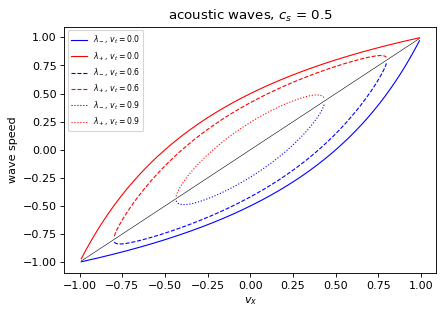

In [2]:
def wave_speeds(vx, vt, cs):
    W2 = 1.0 / (1.0 - vx**2 - vt**2)
    sig = cs**2 / (W2 * (1.0 - cs**2))
    root = np.sqrt(sig * (1.0 - vx**2 + sig))
    return (vx - root) / (1.0 + sig), (vx + root) / (1.0 + sig)

cs = 0.5
vx = np.linspace(-0.99, 0.99, 400)
lm, lp = wave_speeds(vx, 0.0, cs)
print("without transverse velocity the estimate equals (v -+ c)/(1 -+ v c):",
      np.allclose(lm, (vx - cs) / (1 - vx * cs)), np.allclose(lp, (vx + cs) / (1 + vx * cs)))

plt.figure(figsize=(6, 4))
for vt, ls in [(0.0, '-'), (0.6, '--'), (0.9, ':')]:
    ok = vx**2 + vt**2 < 1.0
    lm, lp = wave_speeds(vx[ok], vt, cs)
    plt.plot(vx[ok], lm, 'b' + ls, lw=1, label=rf'$\lambda_-$, $v_t = {vt}$')
    plt.plot(vx[ok], lp, 'r' + ls, lw=1, label=rf'$\lambda_+$, $v_t = {vt}$')
plt.plot(vx, vx, 'k', lw=0.5)
plt.xlabel('$v_x$'); plt.ylabel('wave speed'); plt.legend(fontsize=7); plt.title(f'acoustic waves, $c_s$ = {cs}')
plt.show()

The acoustic speeds never exceed the speed of light, and a transverse velocity pulls them towards
$v_x$: in a fast-moving frame the sound cone is contracted by time dilation. For $v_t \to 1$ both
acoustic waves move with the flow.

## 2. From conserved to primitive variables

In Newtonian hydrodynamics $\rho$, $\mathbf{v}$, $p$ follow from $(\rho, \rho\mathbf{v}, E)$ by division and
subtraction. Here the Lorentz factor, which is needed to separate $\rho$ from $D$, depends on the
velocity, which depends on the enthalpy, which depends on the pressure. Everything can be expressed in
terms of one unknown. Using $E + p = \rho h W^2$ and $D = \rho W$,

$$\mathbf{v} = \frac{\mathbf{S}}{E + p}, \qquad
  W(p) = \frac{E + p}{\sqrt{(E + p)^2 - S^2}}, \qquad
  f(p) \equiv D\,W(p) + \frac{\gamma}{\gamma - 1}\,p\,W(p)^2 - (E + p) = 0 .$$

Piastra solves $f(p) = 0$ by Newton's method in every cell, starting from the pressure of the previous
step, and falls back to bisection whenever a Newton step would leave the physical domain
$E + p > |\mathbf{S}|$ (which guarantees $|\mathbf{v}| < 1$). A physical state requires
$E^2 > S^2 + D^2$; truncation errors can violate this, and the code then applies floors. Here is the
function $f(p)$ for a state moving with $W = 10$, and the Newton iteration:

conserved: D = 10.0000, S = 124.3734, E = 124.9000
plain Newton from a poor guess, p = 1:
   iteration 0: p = 1.000000000000   f(p) =  4.22e+01
   iteration 1: p = -1.760849398555   f(p) =  1.05e+02
   iteration 2: p = nan   f(p) =  nan
   iteration 3: p = nan   f(p) =  nan
   iteration 4: p = nan   f(p) =  nan
   iteration 5: p = nan   f(p) =  nan
   iteration 6: p = nan   f(p) =  nan
   iteration 7: p = nan   f(p) =  nan
safeguarded Newton (as in Piastra) from the same guess:
   iteration 0: p = 1.000000000000   f(p) =  4.22e+01
   iteration 1: p = 0.500000000001   f(p) =  2.96e+01
   iteration 2: p = 0.250000000001   f(p) =  1.53e+01
   iteration 3: p = 0.057339916393   f(p) = -6.02e+00
   iteration 4: p = 0.096711580814   f(p) = -4.31e-01
   iteration 5: p = 0.099980269185   f(p) = -2.57e-03
   iteration 6: p = 0.099999999289   f(p) = -9.26e-08
   iteration 7: p = 0.100000000000   f(p) =  3.98e-13
   iteration 8: p = 0.100000000000   f(p) = -3.69e-13
   iteration 9: p = 0.100000000

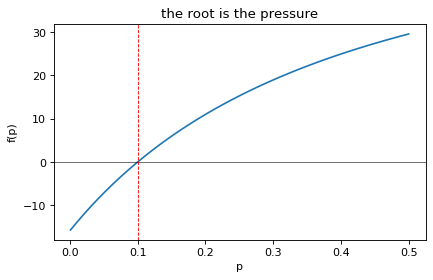

In [3]:
eos = EOSdata(5.0 / 3.0)
W_true, rho_true, p_true = 10.0, 1.0, 0.1
v_true = np.sqrt(1.0 - 1.0 / W_true**2)
one = np.ones((1, 1))
D, S, S2, S3, E = prim2cons_rHD(rho_true * one, v_true * one, 0 * one, 0 * one, p_true * one, eos)
print(f"conserved: D = {D[0, 0]:.4f}, S = {S[0, 0]:.4f}, E = {E[0, 0]:.4f}")

p = np.linspace(1e-3, 0.5, 400)
f = [_pres_eqn_sr(pi * one, D, S**2, E, eos.GAMMA)[0, 0] for pi in p]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(p, f); ax.axhline(0, color='k', lw=0.5); ax.axvline(p_true, color='r', ls='--', lw=0.8)
ax.set_xlabel('p'); ax.set_ylabel('f(p)'); ax.set_title('the root is the pressure')
plt.show()

def newton(p_start, safeguard, n_iter=8):
    '''Newton's method for f(p) = 0; with the safeguard used by Piastra, a step that leaves the
    physical domain E + p > |S| (or produces a non-finite value) is replaced by a bisection
    towards the edge of the domain.'''
    p_lim = max(1e-12, (1.0 + 1e-10) * abs(S[0, 0]) - E[0, 0])
    pk = p_start * one
    for k in range(n_iter):
        fk = _pres_eqn_sr(pk, D, S**2, E, eos.GAMMA)
        print(f"   iteration {k}: p = {pk[0, 0]:.12f}   f(p) = {fk[0, 0]: .2e}")
        p_new = pk - fk / _pres_der_sr(pk, D, S**2, E, eos.GAMMA)
        if safeguard and (not np.isfinite(p_new[0, 0]) or p_new[0, 0] <= p_lim):
            p_new = 0.5 * (pk + p_lim)
        pk = p_new

print("plain Newton from a poor guess, p = 1:")
newton(1.0, safeguard=False)
print("safeguarded Newton (as in Piastra) from the same guess:")
newton(1.0, safeguard=True, n_iter=10)
print("plain Newton from a good guess (the pressure of the previous step), p = 0.12:")
newton(0.12, safeguard=False, n_iter=5)

Three lessons in one cell. From a poor starting value the plain Newton step jumps to a negative
pressure, where $W(p)$ is not even defined, and the iteration breaks down. The safeguarded iteration
bisects back into the physical domain and then converges. And from a good starting value — in a
simulation, the pressure of the same cell at the previous step — Newton's method converges
quadratically: the number of correct digits roughly doubles with each iteration.

The real difficulty lies elsewhere: the inversion is **ill-conditioned** for fast flows. The
rest-frame information is hidden in small differences of large laboratory-frame numbers — for example
$(E + p)^2 - S^2 = (\rho h W)^2$, while $E$ and $|\mathbf{S}|$ are both of order $\rho h W^2$. A relative
error $\varepsilon$ in $E$ therefore changes the rest-frame quantities by about $2W^2\varepsilon$, and
for a cold gas the pressure, a small part of the energy, suffers even more. We perturb $E$ by one part
in $10^{12}$ — the size of accumulated round-off — and recover the pressure of a cold gas:

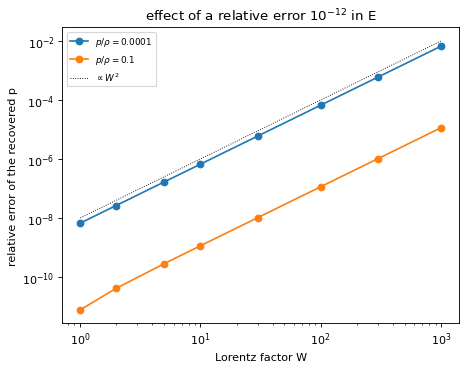

In [4]:
Ws = np.array([1.01, 2.0, 5.0, 10.0, 30.0, 100.0, 300.0, 1000.0])
for p_over_rho in [1e-4, 1e-1]:
    errors = []
    for W in Ws:
        v = np.sqrt(1.0 - 1.0 / W**2)
        D, S, S2, S3, E = prim2cons_rHD(one, v * one, 0 * one, 0 * one, p_over_rho * one, eos)
        with contextlib.redirect_stdout(io.StringIO()):
            rho_r, v_r, _, _, p_r = cons2prim_rHD(D, S, S2, S3, E * (1.0 + 1e-12), p_over_rho * one, eos)
        errors.append(abs(p_r[0, 0] / p_over_rho - 1.0))
    plt.loglog(Ws, errors, 'o-', label=rf'$p/\rho = {p_over_rho:g}$')
plt.loglog(Ws, 1e-8 * Ws**2, 'k:', lw=0.8, label=r'$\propto W^2$')
plt.xlabel('Lorentz factor W'); plt.ylabel('relative error of the recovered p')
plt.title(r'effect of a relative error $10^{-12}$ in E'); plt.legend(fontsize=8)
plt.show()

At $W = 1000$ a round-off-sized error in the energy produces a per-cent error in the pressure of a cold
flow. This is why ultra-relativistic simulations are hard, why they rely on floors, and why a
conservative-to-primitive inversion that "fails" is not necessarily a bug in the inversion: it may be
the scheme that produced an unphysical conserved state.

## 3. Reconstruction: why the four-velocity

A second-order scheme reconstructs values at the cell faces. In Newtonian hydrodynamics Piastra
reconstructs $\rho$, $\mathbf{v}$, $p$. In rHD the velocity has to satisfy $|\mathbf{v}| < 1$, and this
constraint is nonlinear: a limiter keeps each *component* between the neighbouring values, but not the
length of the vector. Piastra therefore reconstructs the spatial part of the four-velocity,
$\mathbf{u} = W\mathbf{v}$, which is unconstrained, and recovers
$\mathbf{v} = \mathbf{u}/\sqrt{1 + u^2}$ at the face — any $\mathbf{u}$ gives a subluminal $\mathbf{v}$.

To see the difference we reconstruct a velocity field whose direction rotates while its magnitude stays
$|\mathbf{v}| = 0.999$ — something like the flow around a vortex or a bent jet:

reconstruction  max |v| at the faces:  from v      from u = W v
PLM                                    1.1046      0.999182
PPM                                    1.1090      0.999188
WENO                                   1.0106      0.999023
MP5                                    1.0133      0.999028


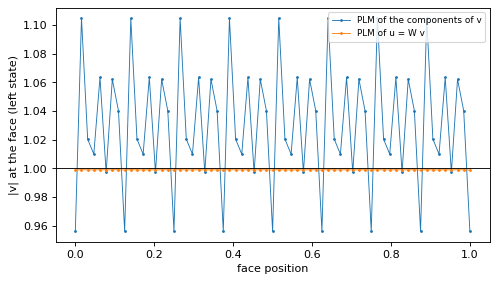

In [5]:
grid = Grid(64, 1, 3)
grid.CartesianGrid(0.0, 1.0, 0.0, 1.0)
x = grid.cx1
vx, vy = 0.999 * np.cos(12 * np.pi * x), 0.999 * np.sin(12 * np.pi * x)
W = 1.0 / np.sqrt(1.0 - vx**2 - vy**2)
xf = grid.fx1[grid.Ngc:grid.Nx1r + 1, grid.Ngc]      # face positions

fig, ax = plt.subplots(figsize=(7, 3.8))
print(f"{'reconstruction':15s} max |v| at the faces:  from v      from u = W v")
for rec in ['PLM', 'PPM', 'WENO', 'MP5']:
    vxL, vxR = VarReconstruct(vx, grid, rec, 1); vyL, vyR = VarReconstruct(vy, grid, rec, 1)
    uxL, uxR = VarReconstruct(W * vx, grid, rec, 1); uyL, uyR = VarReconstruct(W * vy, grid, rec, 1)
    from_v = np.hypot(vxL, vyL)[:, 0]
    from_u = (np.hypot(uxL, uyL) / np.sqrt(1.0 + uxL**2 + uyL**2))[:, 0]
    print(f"{rec:15s}                        {from_v.max():.4f}      {from_u.max():.6f}")
    if rec == 'PLM':
        ax.plot(xf, from_v, '.-', ms=3, lw=0.8, label='PLM of the components of v')
        ax.plot(xf, from_u, '.-', ms=3, lw=0.8, label='PLM of u = W v')
ax.axhline(1.0, color='k', lw=0.8)
ax.set_xlabel('face position'); ax.set_ylabel('|v| at the face (left state)'); ax.legend(fontsize=8)
plt.show()

Reconstructing the components of $\mathbf{v}$ produces face states moving faster than light — with every
reconstruction, including the limited PLM — and the conversion to conserved variables would fail there.
Reconstructing $\mathbf{u}$ can never do this.

Piastra adds one more safeguard. A face is marked as **troubled** if a reconstructed density or
pressure is not positive, or if the pressures of the two neighbouring cells differ by more than a third
(a strong shock). At troubled faces the high-order reconstruction (PPM, WENO, MP5) is replaced by the
more robust piecewise-linear one with the van Leer limiter — a simple form of the "fallback" strategies
used in production codes.

## 4. Riemann solvers and one-dimensional tests

The rHD module offers the local Lax–Friedrichs (LLF), HLL, and HLLC fluxes; the relativistic HLLC solver
of Mignone & Bodo (2005) restores the contact discontinuity. Piastra has no exact relativistic Riemann
solver (see Martí & Müller 1994 and Pons et al. 2000 for one), so the reference solutions below are
computed with 3200 cells. All runs use PLM, RK2, and the Courant number 0.4.

**Problem 1: a relativistic stream hitting a high-pressure gas** (`RP1`; Mignone & Bodo 2005):
$(\rho, v, p) = (1, 0.9, 1)$ on the left, $(1, 0, 10)$ on the right, $\gamma = 5/3$.

LLF  : L1 error of density 0.0231
HLL  : L1 error of density 0.0222
HLLC : L1 error of density 0.0175


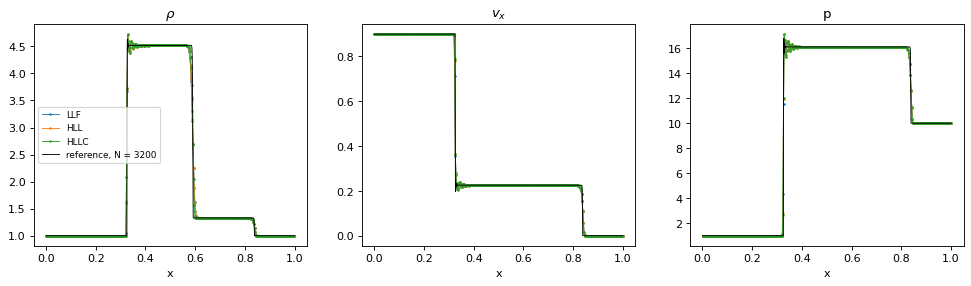

In [6]:
def compare_solvers(problem, N=400, N_ref=3200, zoom=None):
    grid, state, par, eos, solver = setup(problem, N_ref, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    state = evolve(solver, par)
    x_ref = profile(grid, state.dens)[0]
    ref = {k: profile(grid, getattr(state, k))[1] for k in ['dens', 'vel1', 'pres']}
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    for s in ['LLF', 'HLL', 'HLLC']:
        grid, state, par, eos, solver = setup(problem, N, rec_type='PLM', RK_order='RK2', solver_type=s)
        state = evolve(solver, par)
        x = profile(grid, state.dens)[0]
        for ax, k in zip(axes, ['dens', 'vel1', 'pres']):
            ax.plot(x, profile(grid, getattr(state, k))[1], '.-', ms=2.5, lw=0.8, label=s)
        rho = profile(grid, state.dens)[1]
        print(f"{s:5s}: L1 error of density {np.mean(np.abs(rho - np.interp(x, x_ref, ref['dens']))):.4f}")
    for ax, k, name in zip(axes, ['dens', 'vel1', 'pres'], [r'$\rho$', '$v_x$', 'p']):
        ax.plot(x_ref, ref[k], 'k-', lw=0.8, label=f'reference, N = {N_ref}')
        ax.set_xlabel('x'); ax.set_title(name)
        if zoom is not None:
            ax.set_xlim(*zoom)
    axes[0].legend(fontsize=8)
    plt.show()

compare_solvers("RP1")

The stream is decelerated by a reverse shock, and a shock runs into the high-pressure gas; between them
the shocked gases are separated by a contact. HLLC resolves the contact more sharply than HLL and LLF
and has the smallest error, as in Newtonian hydrodynamics.

**Problem 2: a relativistic blast wave** (`RP3`; Martí & Müller 2003, problem 1): a hot, dense gas
($\rho = 10$, $p = 13.33$) expands into a cold one ($\rho = 1$, $p \approx 0$). The shock is preceded by a
dense shell of swept-up gas moving at $v \approx 0.72$:

LLF  : L1 error of density 0.0353
HLL  : L1 error of density 0.0324
HLLC : L1 error of density 0.0323


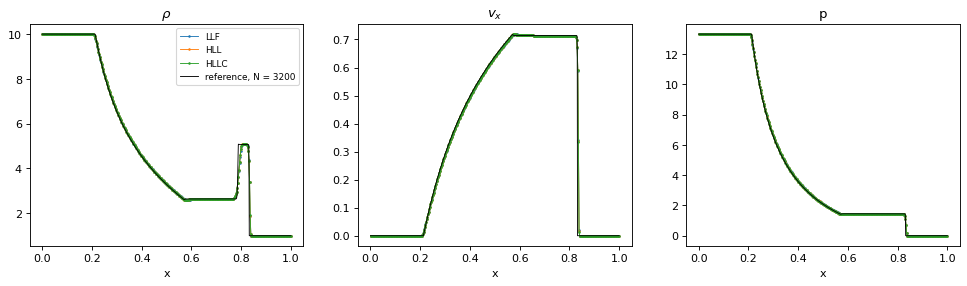

In [7]:
compare_solvers("RP3")

**Problem 3: a strong blast wave** (`RP4`; Martí & Müller 2003, problem 2): the pressure ratio is $10^5$,
and the swept-up shell is extremely thin and moves with $W \approx 3.6$. Here the solvers barely differ —
all of them are limited by resolution. We therefore compare resolutions instead:

N =   200: peak density of the shell   4.91
N =   400: peak density of the shell   6.44
N =   800: peak density of the shell   8.13
N =  1600: peak density of the shell   9.61
N =  3200: peak density of the shell  10.31


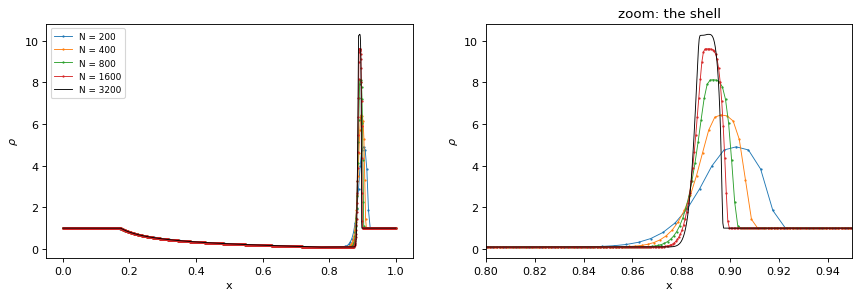

In [8]:
grid, state, par, eos, solver = setup("RP4", 3200, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
state = evolve(solver, par)
x_ref, rho_ref = profile(grid, state.dens)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for N in [200, 400, 800, 1600]:
    grid, state, par, eos, solver = setup("RP4", N, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    state = evolve(solver, par)
    x, rho = profile(grid, state.dens)
    for ax in axes:
        ax.plot(x, rho, '.-', ms=2, lw=0.8, label=f'N = {N}')
    print(f"N = {N:5d}: peak density of the shell {rho.max():6.2f}")
print(f"N =  3200: peak density of the shell {rho_ref.max():6.2f}")
for ax in axes:
    ax.plot(x_ref, rho_ref, 'k-', lw=0.8, label='N = 3200'); ax.set_xlabel('x'); ax.set_ylabel(r'$\rho$')
axes[1].set_xlim(0.8, 0.95); axes[1].set_title('zoom: the shell')
axes[0].legend(fontsize=8)
plt.show()

The shell is so thin that even 1600 cells underestimate its peak density considerably, and the peak
still grows between 1600 and 3200 cells, so the reference is not fully converged either. Thin shells
behind strong relativistic shocks are a standard difficulty and one of the reasons relativistic codes
use adaptive mesh refinement.

**Problem 4: the same blast wave with transverse velocity** (`RP5`): the only change with respect to
`RP4` is a velocity $v_y = 0.99$ *parallel* to the initial discontinuity in the cold gas. In Newtonian
hydrodynamics a tangential velocity is simply advected and does not change the solution in the
$x$-direction at all. In relativity it changes the Lorentz factor, and with it the inertia of the gas:

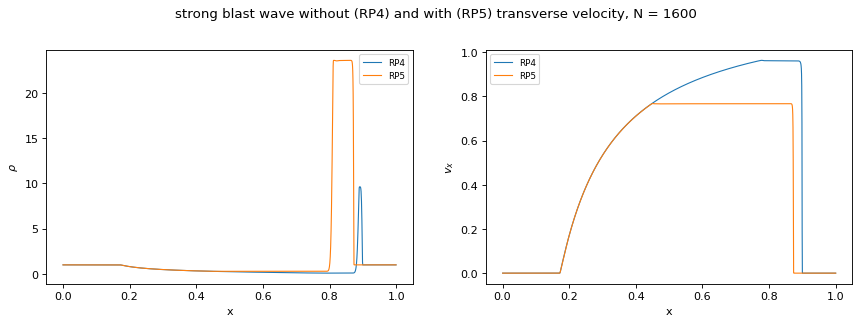

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for problem in ['RP4', 'RP5']:
    grid, state, par, eos, solver = setup(problem, 1600, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    state = evolve(solver, par)
    axes[0].plot(*profile(grid, state.dens), lw=1, label=problem)
    axes[1].plot(*profile(grid, state.vel1), lw=1, label=problem)
axes[0].set_ylabel(r'$\rho$'); axes[1].set_ylabel('$v_x$')
for ax in axes:
    ax.set_xlabel('x'); ax.legend(fontsize=8)
plt.suptitle('strong blast wave without (RP4) and with (RP5) transverse velocity, N = 1600', y=1.02)
plt.show()

The cold gas with $W \approx 7$ is much harder to push, so the shock is slower and the swept-up shell
denser. Transverse velocities couple to the normal flow only through the Lorentz factor, but this
coupling makes relativistic Riemann problems with shear notoriously difficult to resolve (Pons et al.
2000).

## 5. A relativistic jet

A light, hot, relativistic beam ($v = 0.99$, $W \approx 7$, density ratio $\eta = 10^{-2}$, in pressure
equilibrium with the surroundings) is injected through a nozzle into an axisymmetric $(R, z)$ domain
(`jet2Dcyl`). As in the Newtonian case, a bow shock, a cocoon of shocked beam material, and a working
surface at the head form. The head advances at the speed set by the balance of momentum fluxes in its
frame, the relativistic generalization of the Newtonian estimate (Martí et al. 1997):

$$v_h = \frac{v_j}{1 + \eta_r^{-1/2}}, \qquad
  \eta_r = \frac{\rho_j h_j W_j^2}{\rho_a h_a} .$$

Relativistic inertia is carried by the enthalpy and boosted by $W^2$: a jet a hundred times lighter than
its surroundings behaves, as far as its head is concerned, like a jet of almost the same density. We run
the problem with HLL and HLLC:

HLL : bow shock on the axis at z = 14.8 at t = 30; maximum Lorentz factor 7.16
HLLC: bow shock on the axis at z = 14.8 at t = 30; maximum Lorentz factor 8.45
eta = 0.010, eta_r = 0.914: v_h = 0.484, predicted head position at t = 30: z = 14.5


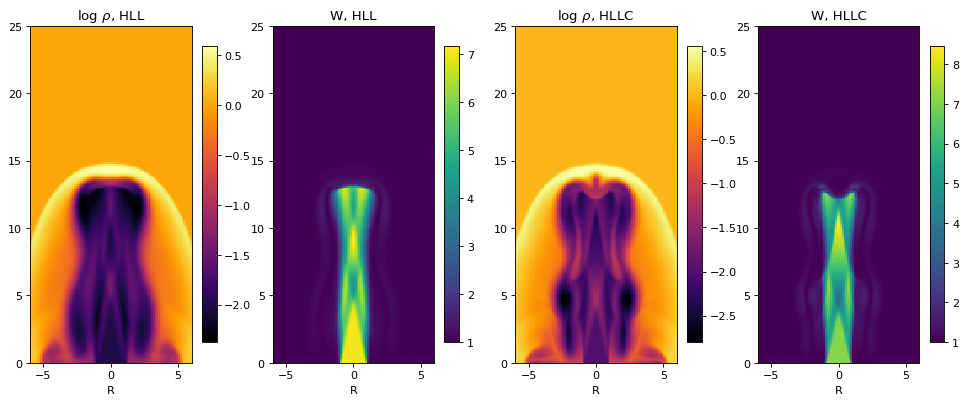

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 8))
for k, s in enumerate(['HLL', 'HLLC']):
    grid, state, par, eos, solver = setup("jet2Dcyl", 48, 200, rec_type='PLM', RK_order='RK2', solver_type=s)
    jet = par.BC_fixed[1][0][2]                         # the state injected through the nozzle
    state = evolve(solver, par)
    R, z, rho = interior(grid, grid.cx1), interior(grid, grid.cx2), interior(grid, state.dens)
    W = 1.0 / np.sqrt(1.0 - interior(grid, state.vel1)**2 - interior(grid, state.vel2)**2)
    Rm = np.concatenate([-R[::-1], R]); zm = np.concatenate([z[::-1], z])
    for ax, f, name, cmap in [(axes[2 * k], np.log10(rho), r'log $\rho$', 'inferno'),
                              (axes[2 * k + 1], W, 'W', 'viridis')]:
        im = ax.pcolormesh(Rm, zm, np.concatenate([f[::-1], f]), shading='auto', cmap=cmap)
        ax.set_aspect('equal'); ax.set_title(f'{name}, {s}'); ax.set_xlabel('R')
        plt.colorbar(im, ax=ax, shrink=0.6)
    head = z[0, np.abs(rho[0, :] / rho[0, -1] - 1.0) > 0.05].max()
    print(f"{s:4s}: bow shock on the axis at z = {head:.1f} at t = {par.timenow:.0f}; "
          f"maximum Lorentz factor {W.max():.2f}")
plt.show()

gam = eos.GAMMA
rho_j, p_j = jet['dens'], jet['pres']
v_j = jet['vel2']
W_j = 1.0 / np.sqrt(1.0 - v_j**2)
h_j = 1.0 + gam / (gam - 1.0) * p_j / rho_j
rho_a, p_a = rho[-1, -1], interior(grid, state.pres)[-1, -1]
h_a = 1.0 + gam / (gam - 1.0) * p_a / rho_a
eta_r = rho_j * h_j * W_j**2 / (rho_a * h_a)
v_h = v_j / (1.0 + eta_r**-0.5)
print(f"eta = {rho_j / rho_a:.3f}, eta_r = {eta_r:.3f}: v_h = {v_h:.3f}, "
      f"predicted head position at t = {par.timenow:.0f}: z = {v_h * par.timenow:.1f}")

The measured head position agrees with the one-dimensional momentum balance to a few per cent, and
HLL and HLLC give the same global dynamics. The beam, however, is not uniform: the overpressured cocoon
squeezes it, and a chain of internal (recollimation) shocks forms along the axis. The Lorentz factor
drops at each of them and rises again in the expansion behind, locally exceeding the injection value
$W \approx 7$. HLLC, the less diffusive solver, preserves this structure over the whole beam; with HLL
the upper part of the beam is smeared, and the maximum Lorentz factor is lower. The cocoon itself is
slow ($W \approx 1$) and hot.

## Summary

* The conserved variables of rHD mix the rest-frame quantities through the Lorentz factor; recovering
  the primitive variables requires the solution of a nonlinear equation in every cell, and this step is
  ill-conditioned for fast flows (errors grow as $W^2$).
* Reconstructing the four-velocity instead of the velocity guarantees subluminal face states; the
  velocity constraint is a nonlinear constraint on a vector and is broken by component-wise limiting.
* The Riemann-solver ladder (LLF, HLL, HLLC) behaves as in Newtonian hydrodynamics; thin shells and
  transverse velocities, not the solver, limit the accuracy of strong relativistic blast waves.
* The relativistic jet head obeys the momentum balance with the relativistic inertia $\rho h W^2$.

## Exercises

1. Replace the reconstruction of $\mathbf{u}$ by that of $\mathbf{v}$ in `flux_calc_rHD` and run the
   relativistic jet or the 2D Riemann problem `RP2D`. Where and when does the code fail?
2. Measure how many Newton iterations the pressure recovery needs per cell in the `RP4` problem, and how
   the number changes if the initial guess is not the pressure of the previous step.
3. Run `RP4` with PPM and MP5 at $N = 400$ and count the faces marked as troubled. Where are they?
4. Take the limit $v \ll 1$, $p \ll \rho$ of the rHD equations and show that $E - D$ reduces to the
   Newtonian total energy. Then run `RP1` with all velocities divided by ten and compare with a Newtonian
   run of the same problem.
5. Increase the jet velocity to $v = 0.999$ ($W \approx 22$) and compare the head speed with the
   estimate. What limits the maximum Lorentz factor the code can handle?